# Demo đọc dữ liệu bằng Pandas


## Chuẩn bị trên Google Colab

Notebook sẽ tự tạo file `orders_demo_beginner.csv` trong môi trường Colab. Sau đó, ta sẽ dùng Pandas để đọc file này như một file CSV bình thường.

Cách thực hành:

1. Mở notebook trên Google Colab.
2. Chạy từng cell từ trên xuống dưới.
3. Quan sát kết quả sau mỗi cell.


In [ ]:
# Cell 1: Import các thư viện cần dùng

# Pandas là thư viện Python thường dùng để làm việc với dữ liệu dạng bảng.
# Ta đặt bí danh là pd để viết code ngắn gọn hơn.
# Path được dùng để tạo và kiểm tra file trong thư mục làm việc hiện tại của Colab.
from pathlib import Path

# Matplotlib được dùng để hiển thị biểu đồ sau khi Pandas vẽ chart.
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Cell 2: Tạo sẵn file CSV mẫu trong Google Colab

csv_content = """OrderID,Customer,City,Product,Quantity,Total,Status
O101,An,HCM,Mouse,2,300000,Done
O102,Binh,HN,Keyboard,1,750000,Done
O103,Chi,HN,Monitor,1,2000000,Done
O104,Dung,Da Nang,USB,3,120000,Done
O105,Em,HCM,Laptop Stand,1,450000,Pending
O106,Giang,Can Tho,Mouse,1,150000,Done
O107,Hoa,HN,Webcam,1,850000,Done
O108,Khanh,HCM,Keyboard,2,1500000,Done
O109,Lan,Da Nang,Headphone,1,650000,Canceled
O110,Minh,HCM,Monitor,1,2200000,Done
"""

# Đặt tên file CSV sẽ được tạo trong thư mục làm việc hiện tại.
file_path = "orders_demo_beginner.csv"

# Ghi nội dung CSV vào file.
Path(file_path).write_text(csv_content, encoding="utf-8")

# In thông báo để biết file đã được tạo thành công.
print(f"Đã tạo file: {file_path}")
print("Bây giờ ta có thể đọc file này bằng Pandas.")

Đã tạo file: orders_demo_beginner.csv
Bây giờ ta có thể đọc file này bằng Pandas.


In [ ]:
# Cell 3: Đọc file CSV bằng Pandas

# read_csv() dùng để đọc dữ liệu từ file CSV.
# Kết quả đọc được lưu vào biến df.
# df là viết tắt của DataFrame, có thể hiểu như một bảng dữ liệu trong Python.
df = pd.read_csv(file_path)

In [ ]:
# Cell 4: Xem vài dòng đầu tiên

# df.head() hiển thị 5 dòng đầu tiên của bảng dữ liệu.
# Mục đích: kiểm tra dữ liệu đã được đọc đúng chưa.
df.head()

,OrderID,Customer,City,Product,Quantity,Total,Status
0,O101,An,HCM,Mouse,2,300000,Done
1,O102,Binh,HN,Keyboard,1,750000,Done
2,O103,Chi,HN,Monitor,1,2000000,Done
3,O104,Dung,Da Nang,USB,3,120000,Done
4,O105,Em,HCM,Laptop Stand,1,450000,Pending


In [ ]:
# Cell 5: Xem số dòng, số cột và tên các cột

# df.shape cho biết kích thước của bảng dữ liệu.
# Kết quả có dạng: (số dòng, số cột).
print("Số dòng, số cột:", df.shape)

# df.columns cho biết danh sách tên các cột trong bảng.
print("Tên các cột:")
print(df.columns)

Số dòng, số cột: (10, 7)
Tên các cột:
Index(['OrderID', 'Customer', 'City', 'Product', 'Quantity', 'Total',
       'Status'],
      dtype='object')


In [ ]:
# Cell 6: Kiểm tra Missing Value

# isna() kiểm tra ô nào bị thiếu dữ liệu.
# sum() đếm số lượng giá trị bị thiếu ở từng cột.
# Nếu một cột có kết quả bằng 0, nghĩa là cột đó không bị thiếu dữ liệu.
df.isna().sum()

,0
OrderID,0
Customer,0
City,0
Product,0
Quantity,0
Total,0
Status,0


City
Can Tho    1
Da Nang    2
HCM        4
HN         3
Name: OrderID, dtype: int64


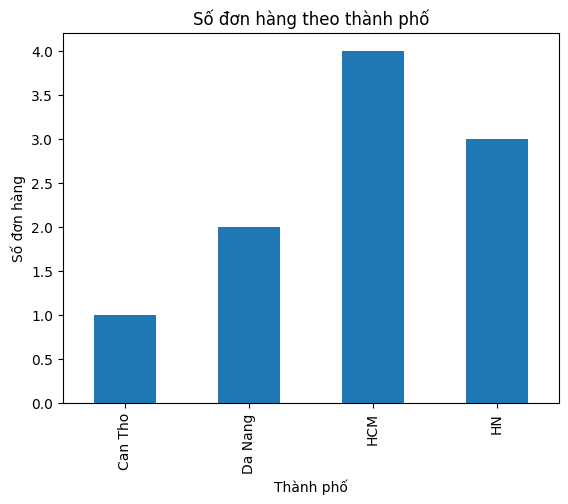

In [ ]:
# Cell 7: Vẽ biểu đồ cột đơn giản

# Câu hỏi phân tích: Thành phố nào có nhiều đơn hàng nhất?

# groupby("City") gom các dòng theo từng thành phố.
# ["OrderID"].count() đếm số đơn hàng trong mỗi thành phố.
orders_by_city = df.groupby("City")["OrderID"].count()

# Hiển thị bảng tổng hợp trước khi vẽ chart.
print(orders_by_city)

# Vẽ biểu đồ cột để so sánh số đơn hàng giữa các thành phố.
orders_by_city.plot(kind="bar", title="Số đơn hàng theo thành phố")

# Đặt tên cho trục x và trục y để biểu đồ dễ hiểu hơn.
plt.xlabel("Thành phố")
plt.ylabel("Số đơn hàng")

# Hiển thị biểu đồ.
plt.show()